# 5A. Reporte escrito. Experimentos y análisis de algoritmos de intersección de conjuntos

**Nombre alumna:** Jovanna del Rocío Aguilar López

## Introducción 
La intersección de listas ordenadas consiste en encontrar los elementos que aparecen en todas las listas analizadas. Este problema es importante porque se usa cuando los datos ya están organizados, por ejemplo, en listas de documentos, índices invertidos o conjuntos ordenados. En esta práctica se implementan y comparan tres algoritmos de intersección: Melding (ME), Baeza-Yates (BY) y Barbay & Kenyon (BK), con el objetivo de obtener la intersección correcta y analizar su tiempo de ejecución y número de comparaciones.

El algoritmo Melding (ME) se relaciona con la idea de fusionar listas ordenadas. Hwang y Lin explican que el problema de mezcla consiste en determinar el orden de la unión mediante comparaciones entre elementos. En este caso, la idea se retoma para recorrer las listas de forma ordenada y avanzar conforme se comparan sus valores.

Por otro lado, Baeza-Yates (BY) utiliza una estrategia de “double binary search”, donde se busca la mediana de una lista dentro de la otra y después se resuelven las partes izquierda y derecha. En la práctica, este algoritmo se implementa con bisección, $B_1$ y $B_2$, para observar si cambia el número de comparaciones.

Finalmente, Barbay & Kenyon (BK) parte de una idea adaptativa, es decir, busca que el algoritmo sea más rápido cuando la instancia es más sencilla. Para ello, aprovecha que las listas están ordenadas y conserva las posiciones ya revisadas para evitar repetir trabajo.

Para comparar los algoritmos se utilizan tres conjuntos de datos: A, con pares de listas; B, con tripletas; y C, con tuplas de cuatro listas. En cada caso se calcula la intersección, el tiempo de ejecución, el número de comparaciones y la longitud de la intersección.

## Cargamos los conjuntos

In [1]:
import Pkg

Pkg.add("JSON3")
Pkg.add("DataFrames")
Pkg.add("StatsPlots")
Pkg.add("CSV")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using JSON3
using DataFrames
using StatsPlots
using CSV

carpeta = "/Users/enriquear/Downloads/Conjuntos de listas de posteo para intersección-20260518"
cd(carpeta)

readdir()

7-element Vector{String}:
 ".DS_Store"
 "postinglists-for-intersection-A-k=2.json"
 "postinglists-for-intersection-A-k=2.json.gz"
 "postinglists-for-intersection-B-k=3.json"
 "postinglists-for-intersection-B-k=3.json.gz"
 "postinglists-for-intersection-C-k=4.json"
 "postinglists-for-intersection-C-k=4.json.gz"

In [3]:
# Leer el archivo real del conjunto A
A = JSON3.read(read(
    "postinglists-for-intersection-A-k=2.json/postinglists-for-intersection-A-k=2.json",String))
# Leer el archivo real del conjunto B
B = JSON3.read(read(
    "postinglists-for-intersection-B-k=3.json/postinglists-for-intersection-B-k=3.json",String))

# Leer el archivo real del conjunto C
C = JSON3.read(read("postinglists-for-intersection-C-k=4.json/postinglists-for-intersection-C-k=4.json", String))

200-element JSON3.Array{JSON3.Array, Base.CodeUnits{UInt8, String}, Vector{UInt64}}:
 JSON3.Array[[3, 4, 10, 17, 30, 38, 43, 49, 63, 66  …  49863, 49869, 49882, 49883, 49905, 49943, 49963, 49965, 49986, 49987], [243, 1553, 1848, 1887, 1949, 2177, 2402, 2466, 2564, 3005  …  48266, 48333, 48347, 48696, 48838, 49129, 49379, 49714, 49863, 49986], [1848, 3482, 3482, 3626, 4490, 4999, 7169, 7641, 7903, 8256  …  46176, 46404, 46948, 47395, 47465, 47465, 47714, 48089, 48838, 49764], [4, 49, 91, 210, 237, 242, 318, 327, 353, 358  …  48377, 48507, 48844, 48846, 49278, 49331, 49390, 49444, 49667, 49764]]
 JSON3.Array[[43, 334, 367, 412, 493, 935, 1203, 1329, 1367, 1726  …  48369, 48724, 48790, 48932, 49032, 49504, 49519, 49780, 49784, 49880], [13, 26, 42, 45, 132, 134, 150, 165, 172, 210  …  49624, 49661, 49758, 49882, 49905, 49915, 49917, 49971, 49975, 49979], [43, 521, 1203, 1657, 2345, 2445, 2681, 3518, 3798, 4648  …  45407, 45603, 46274, 46655, 47767, 48790, 49262, 49504, 49519, 49519], [2, 3

In [4]:
# Creamos un diccionario para trabajar con A, B y C
conjuntos = Dict(
    "A" => A,
    "B" => B,
    "C" => C
)

# Verificamos cuántas listas tiene el primer caso de cada conjunto
length(A[1]), length(B[1]), length(C[1])

(2, 3, 4)

In [5]:
# Compara si a < b y suma una comparación
function menor_que_conteo(a, b, contador)
    contador[] += 1
    return a < b
end

# Compara si a <= b y suma una comparación
function menor_o_igual_conteo(a, b, contador)
    contador[] += 1
    return a <= b
end

# Compara si a == b y suma una comparación
function igual_conteo(a, b, contador)
    contador[] += 1
    return a == b
end

igual_conteo (generic function with 1 method)

## Implementación de algoritmos

### Algoritmo Melding

El algoritmo de Melding permite obtener la intersección de listas ordenadas revisándolas de izquierda a derecha. En cada paso compara un valor de cada lista. Si los valores son iguales, se agregan al resultado; si son distintos, se avanza en la lista que tiene el valor menor. Esto funciona porque, al estar ordenadas, ese valor menor ya no podrá coincidir con el valor más grande de la otra lista. En términos teóricos, para dos listas de tamaños $m$ y $n$, el algoritmo tiene un costo lineal $O(m+n)$, ya que no compara todos los elementos entre sí, sino que avanza de forma ordenada. Para tres o más listas, se aplica por etapas, iniciando con las listas más pequeñas para reducir los resultados intermedios.

In [7]:
function ME_dos_listas(A, B)

#Creamos un contador para registrar el número de comparaciones
    contador = Ref(0)

#Posición actual en la lista A
    i = 1
#Posición actual en la lista A
    j = 1

#Vector para guardar los elementos comunes
    interseccion = Int[]

#Recorremos ambas listas mientras ninguna haya terminado
    while i <= length(A) && j <= length(B)

#Si el valor aparece en ambas listas, se guarda en la intersección
        if igual_conteo(A[i], B[j], contador)

#Guardamos el elemento común
            push!(interseccion, A[i])

#Avanzamos en ambas listas
            i += 1
            j += 1

        else
#Si A[i] es menor que B[j], avanzamos en A
            if menor_que_conteo(A[i], B[j], contador)
                i += 1

#Si no, avanzamos en B
            else
                j += 1
            end
        end
    end
#Regresamos la intersección y el número de comparaciones realizadas
    return interseccion, contador[]
end

ME_dos_listas (generic function with 1 method)

La función ME_dos_listas implementa el procedimiento básico del algoritmo Melding para dos listas ordenadas. La función ME generaliza este procedimiento para casos con más de dos listas. Primero toma la lista más pequeña como resultado inicial y después la intersecta con cada una de las listas restantes. 

In [9]:
function ME(listas)

#Ordenamos cada lista y eliminamos elementos repetidos
    L = [unique(sort(collect(lista))) for lista in listas]

#Ordenamos las listas por tamaño, de menor a mayor
    sort!(L, by = length)

#Tomamos la lista más pequeña como resultado inicial
    resultado = L[1]

#Contador total de comparaciones
    comparaciones_totales = 0

#Repetimos el proceso con las listas que faltan
    for i in 2:length(L)

#Comparamos el resultado actual con la siguiente lista
        resultado, comps = ME_dos_listas(resultado, L[i])
#Sumamos las comparaciones realizadas
        comparaciones_totales += comps

#Si ya no hay elementos comunes, detenemos el proceso
        if isempty(resultado)
            break
        end
    end
#Regresamos la intersección final y el total de comparaciones
    return resultado, comparaciones_totales
end

ME (generic function with 1 method)

### Baeza-Yates
El algoritmo de Baeza-Yates calcula la intersección de dos listas ordenadas usando una estrategia de división del problema. En lugar de revisar todos los elementos de izquierda a derecha, toma un valor central de la lista más pequeña y lo busca en la otra lista. Si el valor aparece en ambas, se agrega a la intersección. Después, como las listas están ordenadas, el algoritmo repite el proceso con los valores que están antes y después de ese punto. En términos teóricos, si una lista tiene tamaño $m$ y la otra tamaño $n$, con $m≤n$, su costo se aproxima a $O(mlog(n/m))$. Por eso, puede ser útil cuando las listas tienen tamaños distintos, ya que evita recorrer por completo la lista más grande y aprovecha búsquedas más eficientes dentro de ella.

Para implementar Baeza-Yates, primero se definieron las funciones de búsqueda que puede usar el algoritmo. Después se implementó BY para dos listas, tomando como base la lista más pequeña. El algoritmo selecciona un valor central, lo busca en la otra lista y divide el problema en dos partes, los valores menores y los valores mayores. Para trabajar con tres o cuatro listas, BY se aplica paso a paso, intersectando primero dos listas y después usando ese resultado con la siguiente lista. Finalmente, se generan diferentes versiones del algoritmo, cambiando únicamente la búsqueda utilizada: bisección, $B_0$, $B_1$ y $B_2$.

In [12]:
function busqueda_binaria_acotada(A, x; lo=1, hi=length(A), contador=Ref(0))
    while lo <= hi
#Obtenemos el punto medio
        mid = (lo + hi) ÷ 2  
#Comparamos x con A[mid] y se cuenta la operación
        if menor_o_igual_conteo(x, A[mid], contador)  
#Buscamos a la izquierda
            hi = mid - 1               
        else
#Buscamos a la derecha
            lo = mid + 1               
        end
    end
#Regresa la posición donde x debería estar
    return lo
end

busqueda_binaria_acotada (generic function with 1 method)

In [13]:
function biseccion(A, x; contador=Ref(0), p_inicial=1, p_final=length(A))
#Aplicamos búsqueda binaria entre la posición inicial y la posición final
    return busqueda_binaria_acotada(
        A,
        x;
        lo = p_inicial,
        hi = p_final,
        contador = contador
    )
end

biseccion (generic function with 1 method)

In [14]:
function B1(A, x; contador=Ref(0), p_inicial=1, p_final=length(A))
#Si la posición inicial es mayor que la final, ya no hay elementos por revisar
    if p_inicial > p_final
        return p_inicial
    end
#p indica desde dónde empieza la búsqueda binaria después de los saltos
    p = 0
#Tamaño inicial del salto
    i = 1
#Encontramos un intervalo donde pueda estar x
    while p_inicial + i <= p_final && menor_que_conteo(A[p_inicial + i], x, contador)
#Guardamos hasta dónde pudimos avanzar sin pasar x
        p = i
#Aumentamos el salto
        i += i
    end
#Aplicamos búsqueda binaria en el intervalo encontrado
    return busqueda_binaria_acotada(
        A,
        x;
        lo = p_inicial + p,
        hi = min(p_final, p_inicial + i),
        contador = contador
    )
end

B1 (generic function with 1 method)

In [15]:
function B2(A, x; contador=Ref(0), p_inicial=1, p_final=length(A))
#Si la posición inicial es mayor que la final, ya no hay elementos por revisar
    if p_inicial > p_final
        return p_inicial
    end
#Si x es menor o igual al primer valor del rango
    if menor_o_igual_conteo(x, A[p_inicial], contador)
        return p_inicial
    end
#Último salto válido
    p = 0
#Variable para generar saltos doblemente doblados
    i = 1
#Encontramos el rango
    while true
# Salto de la forma 2^(2^i)
        salto = 2^(2^i)
#Si la posición se sale del rango, detenemos
        if p_inicial + salto > p_final
            break
        end
#Si el valor sigue siendo menor que x, avanzamos
        if menor_que_conteo(A[p_inicial + salto], x, contador)
            p = salto
            i += 1
        else
            break
        end
    end
#Aplicamos B1 desde el último salto válido
    return B1(
        A,
        x;
        contador = contador,
        p_inicial = p_inicial + p,
        p_final = p_final
    )
end


B2 (generic function with 1 method)

In [16]:
function BY_dos_listas(A, B, busqueda)
#Contador de comparaciones
    contador = Ref(0)
#Ordenamos las listas y eliminamos repetidos
    A = unique(sort(collect(A)))
    B = unique(sort(collect(B)))
#Usamos como A la lista más pequeña
    if length(B) < length(A)
        A, B = B, A
    end
#Guardamos la intersección
    interseccion = Int[]
#Ejecutamos la función que divide el problema en partes más pequeñas
    BY_recursivo!(
        interseccion,
        A,
        1,
        length(A),
        B,
        1,
        length(B),
        busqueda,
        contador
    )
#Regresamos la intersección y las comparaciones
    return sort(interseccion), contador[]
end

BY_dos_listas (generic function with 1 method)

In [17]:
function BY_recursivo!(
    interseccion,
    A,
    a_inicio,
    a_fin,
    B,
    b_inicio,
    b_fin,
    busqueda,
    contador
)
#Si ya no hay elementos por revisar, se detiene
    if a_inicio > a_fin || b_inicio > b_fin
        return
    end
#Elegimos el elemento de en medio de A
    medio = ceil(Int, (a_inicio + a_fin) / 2)
    mediana = A[medio]
#Buscamos la posición de la mediana en B
    posicion = busqueda(
        B,
        mediana;
        contador = contador,
        p_inicial = b_inicio,
        p_final = b_fin
    )
#Revisamos si la mediana aparece en B
    coincide = false
    if posicion <= b_fin
        coincide = igual_conteo(mediana, B[posicion], contador)
    end
#Revisamos la parte izquierda
    BY_recursivo!(
        interseccion,
        A,
        a_inicio,
        medio - 1,
        B,
        b_inicio,
        posicion - 1,
        busqueda,
        contador
    )
#Si la mediana aparece en ambas listas, se agrega al resultado
    if coincide
        push!(interseccion, mediana)
    end
#Definimos desde dónde empieza la parte derecha de B
    siguiente_inicio_B = coincide ? posicion + 1 : posicion
#Revisamos la parte derecha
    BY_recursivo!(
        interseccion,
        A,
        medio + 1,
        a_fin,
        B,
        siguiente_inicio_B,
        b_fin,
        busqueda,
        contador
    )
end

BY_recursivo! (generic function with 1 method)

In [18]:
function BY(listas, busqueda=biseccion)
#Ordenamos cada lista y eliminamos elementos repetidos
    L = [unique(sort(collect(lista))) for lista in listas]
#Ordenamos las listas por tamaño, de menor a mayor
    sort!(L, by = length)
#Tomamos la lista más pequeña como resultado inicial
    resultado = L[1]
#Contador total de comparaciones
    comparaciones_totales = 0
#Repetimos el proceso con las listas que faltan
    for i in 2:length(L)
#Calculamos la intersección con la siguiente lista
        resultado, comps = BY_dos_listas(resultado, L[i], busqueda)
#Sumamos las comparaciones realizadas
        comparaciones_totales += comps
#Si ya no hay elementos comunes, detenemos el proceso
        if isempty(resultado)
            break
        end
    end
#Regresamos la intersección final y las comparaciones totales
    return resultado, comparaciones_totales
end

BY (generic function with 2 methods)

In [19]:
#BY búsqueda por bisección
function BY_biseccion(listas)
    return BY(listas, biseccion)
end

#BY búsqueda no acotada B1
function BY_B1(listas)
    return BY(listas, B1)
end

#BY búsqueda no acotada B2
function BY_B2(listas)
    return BY(listas, B2)
end

BY_B2 (generic function with 1 method)

### Barbay & Kenyon
El algoritmo de Barbay & Kenyon calcula la intersección de varias listas ordenadas tomando un elemento de referencia. Este elemento se busca en las demás listas sin regresar al inicio, sino continuando desde la última posición revisada. Si aparece en todas las listas, se agrega a la intersección, si no, se actualiza al siguiente valor posible. En el peor caso, para dos listas de tamaños $m$ y $n$, su costo puede verse como lineal, $O(m+n)$. Sin embargo, al ser un método adaptativo, puede reducir comparaciones en ciertos casos porque conserva las posiciones ya revisadas.

In [21]:
function BK(listas)
#Contador de comparaciones
    contador = Ref(0)
#Ordenamos cada lista y eliminamos elementos repetidos
    L = [unique(sort(collect(lista))) for lista in listas]
#Si una lista no tiene datos, no puede haber elementos comunes
    if any(isempty, L)
        return Int[], 0
    end
#Número de listas
    k = length(L)
#Posición actual en cada lista
    posiciones = ones(Int, k)
#Guardamos los valores comunes
    interseccion = Int[]
#Usamos el primer valor de la primera lista para iniciar la búsqueda
    valor_actual = L[1][1]
#Cuenta en cuántas listas aparece el valor actual
    coincidencias = 0
#Recorremos hasta que alguna lista se termine
    while true
#Revisamos el valor actual en cada lista
        for i in 1:k
#Buscamos el valor actual desde la última posición revisada
            posiciones[i] = B1(
                L[i],
                valor_actual;
                contador = contador,
                p_inicial = posiciones[i],
                p_final = length(L[i])
            )
#Si la posición se sale de la lista, ya no hay más intersección
            if posiciones[i] > length(L[i])
                return interseccion, contador[]
            end
#Valor encontrado en la posición actual
            valor = L[i][posiciones[i]]
#Si el valor coincide con el valor actual
            if igual_conteo(valor, valor_actual, contador)
#Aumentamos el número de coincidencias
                coincidencias += 1
#Si apareció en todas las listas, se agrega al resultado
                if coincidencias == k
#Guardamos el valor común
                    push!(interseccion, valor_actual)
#Reiniciamos el conteo de coincidencias
                    coincidencias = 0
#Avanzamos en la lista actual
                    posiciones[i] += 1
#Si la lista actual termina, detenemos el proceso
                    if posiciones[i] > length(L[i])
                        return interseccion, contador[]
                    end
#Actualizamos el valor actual
                    valor_actual = L[i][posiciones[i]]
                end

            else
#Si no coincide, actualizamos el valor actual
                coincidencias = 0
                valor_actual = valor
            end
        end
    end
end

BK (generic function with 1 method)

## Experimentación

In [23]:
algoritmos = Dict(
    "ME" => listas -> ME(listas),

    "BY_biseccion" => listas -> BY_biseccion(listas),
    "BY_B1" => listas -> BY_B1(listas),
    "BY_B2" => listas -> BY_B2(listas),

    "BK" => listas -> BK(listas)
)

Dict{String, Function} with 5 entries:
  "BY_B1"        => #17
  "ME"           => #13
  "BY_biseccion" => #15
  "BK"           => #21
  "BY_B2"        => #19

In [24]:
function ejecutar_experimentos(conjuntos, algoritmos; repeticiones=10)
#Creamos una tabla vacía para guardar los resultados
    resultados = DataFrame(
        conjunto = String[],
        caso = Int[],
        algoritmo = String[],
        repeticion = Int[],
        tiempo_segundos = Float64[],
        comparaciones = Int[],
        longitud_interseccion = Int[] )
#Recorremos cada conjunto: A, B y C
    for nombre_conjunto in ["A", "B", "C"]
#Tomamos los casos del conjunto actual
        casos = conjuntos[nombre_conjunto]
#Recorremos cada caso del conjunto
        for (id_caso, listas) in enumerate(casos)
#Recorremos cada algoritmo
            for (nombre_algoritmo, algoritmo) in algoritmos
#Repetimos varias veces para medir mejor el tiempo
                for r in 1:repeticiones
#Medimos el tiempo de ejecución
                    tiempo = @elapsed begin
                        interseccion, comparaciones = algoritmo(listas)
                    end
#Guardamos los resultados en la tabla
                    push!(
                        resultados,
                        (
                            nombre_conjunto,
                            id_caso,
                            nombre_algoritmo,
                            r,
                            tiempo,
                            comparaciones,
                            length(interseccion)
                        )
                    )
                end
            end
        end
    end

#Regresamos la tabla final de resultados
    return resultados
end

ejecutar_experimentos (generic function with 1 method)

In [25]:
resultados = ejecutar_experimentos(
    conjuntos,
    algoritmos;
   repeticiones = 10)

first(resultados, 10)

Row,conjunto,caso,algoritmo,repeticion,tiempo_segundos,comparaciones,longitud_interseccion
,String,Int64,String,Int64,Float64,Int64,Int64
1,A,1,BY_B1,1,0.314543,1829,2
2,A,1,BY_B1,2,0.00516183,1829,2
3,A,1,BY_B1,3,0.00473925,1829,2
4,A,1,BY_B1,4,0.00477325,1829,2
5,A,1,BY_B1,5,0.00471458,1829,2
6,A,1,BY_B1,6,0.00476558,1829,2
7,A,1,BY_B1,7,0.00471512,1829,2
8,A,1,BY_B1,8,0.00476092,1829,2
9,A,1,BY_B1,9,0.00475871,1829,2


### Boxplot Tiempo en segundos

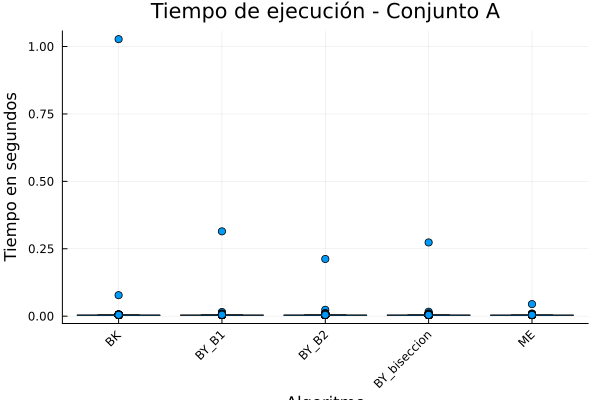

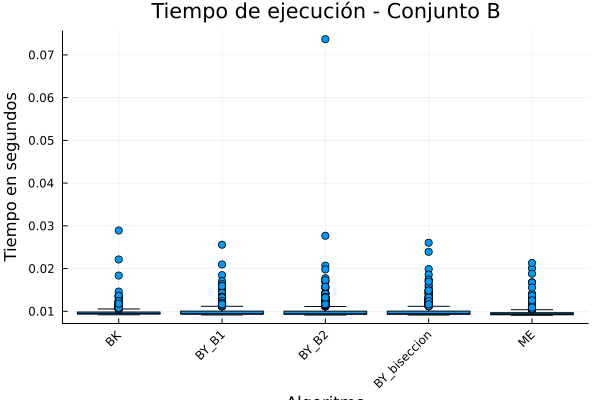

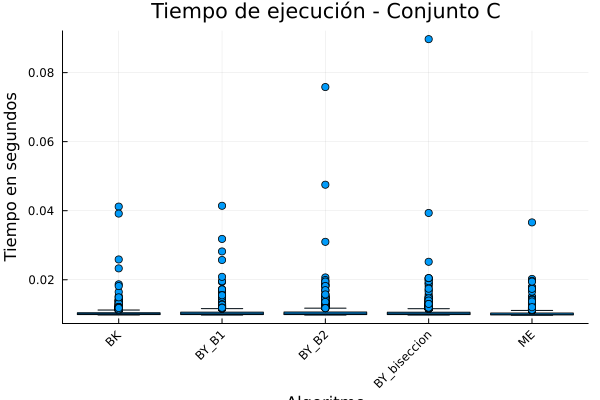

In [60]:
for c in ["A", "B", "C"]

#Filtramos los resultados del conjunto
    df_c = filter(row -> row.conjunto == c, resultados)
#Generamos el boxplot
    p = @df df_c boxplot(
        :algoritmo,
        :tiempo_segundos,
        xlabel = "Algoritmo",
        ylabel = "Tiempo en segundos",
        title = "Tiempo de ejecución - Conjunto $c",
        xrotation = 45,
        legend = false
    )

    display(p)
end

En el conjunto A, se observan algunos valores atípicos más altos, especialmente en BK, que tiene un punto cercano a 1 segundo. También aparecen valores altos en BY_B1, BY_B2 y BY_bisección. Esto puede deberse a la primera ejecución o a variaciones propias de la medición. Aun así, la mayoría de los tiempos se concentran en valores bajos.

En el conjunto B, los tiempos son más estables que en A. La mayoría de los algoritmos se mantiene alrededor de tiempos bajos, aunque BY_B2 presenta un valor atípico más alto, cercano a 0.07 segundos. También hay algunos puntos elevados en BK, BY_B1, BY_bisección y ME, pero no tan extremos como en el conjunto A.

En el conjunto C, los tiempos siguen siendo bajos en general, aunque hay más valores atípicos que en B. BY_bisección y BY_B2 presentan algunos de los puntos más altos. Aun así, las cajas se mantienen cerca entre sí, por lo que no se observa una diferencia muy marcada en el tiempo típico entre algoritmos.

### Boxplot Número de comparaciones 

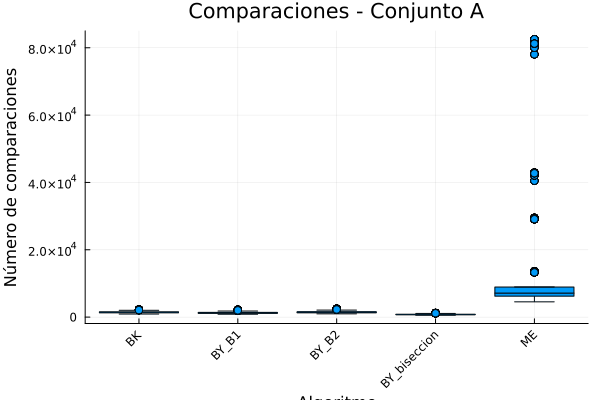

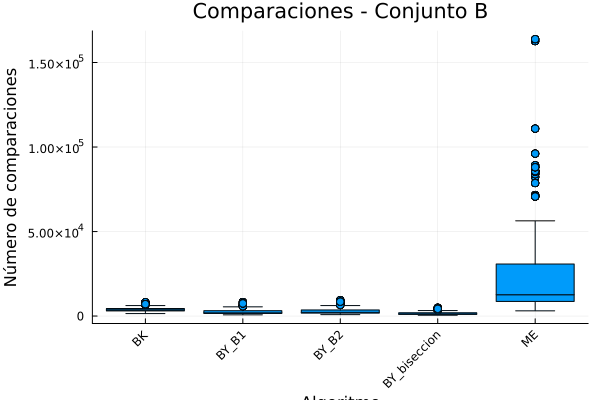

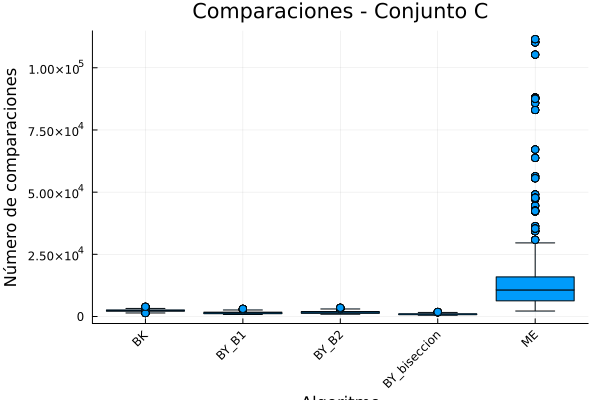

In [27]:
for c in ["A", "B", "C"]
# Filtramos los resultados del conjunto
    df_c = filter(row -> row.conjunto == c, resultados)
# Generamos el boxplot
    p = @df df_c boxplot(
        :algoritmo,
        :comparaciones,
        xlabel = "Algoritmo",
        ylabel = "Número de comparaciones",
        title = "Comparaciones - Conjunto $c",
        xrotation = 45,
        legend = false
    )

    display(p)
end

En el conjunto A, ME hace muchas más comparaciones que los demás algoritmos. Mientras BK, BY_B1, BY_B2 y BY_bisección se mantienen en valores bajos, ME tiene una caja más alta y varios valores extremos. Esto indica que, aunque ME calcula bien la intersección, requiere más trabajo.

En el conjunto B, la diferencia se vuelve todavía más marcada. ME presenta una mayor dispersión y valores mucho más altos que el resto. Los algoritmos BY y BK se mantienen con menos comparaciones, lo que muestra un mejor rendimiento en este aspecto.

En el conjunto C, ME sigue siendo el algoritmo con más comparaciones. Esto es importante porque C tiene cuatro listas, entonces el costo de comparar de forma más directa se acumula más. BY y BK se mantienen en rangos bajos porque aprovechan mejor el orden de las listas.

Los valores atípicos son más significativos porque muestran casos donde el algoritmo necesitó muchas más comparaciones. Esto se observa especialmente en ME, sobre todo en el conjunto C. Esto puede pasar cuando las listas tienen tamaños que obligan al algoritmo a revisar más elementos antes de encontrar la intersección.

### Boxplot Longitudes de las intersecciones 

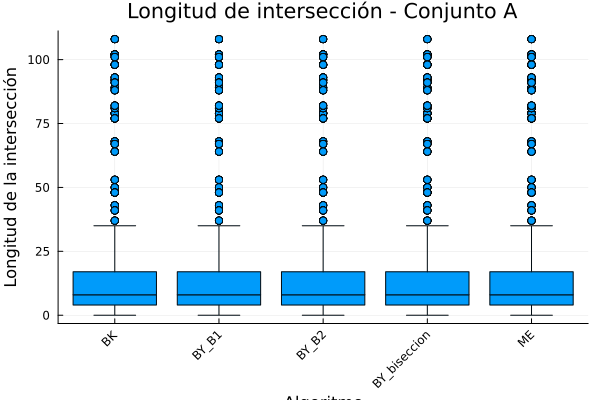

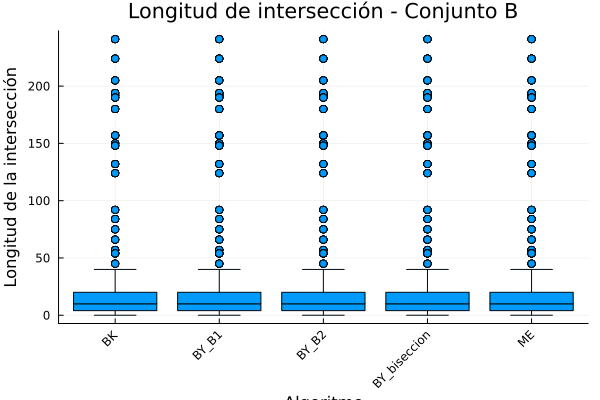

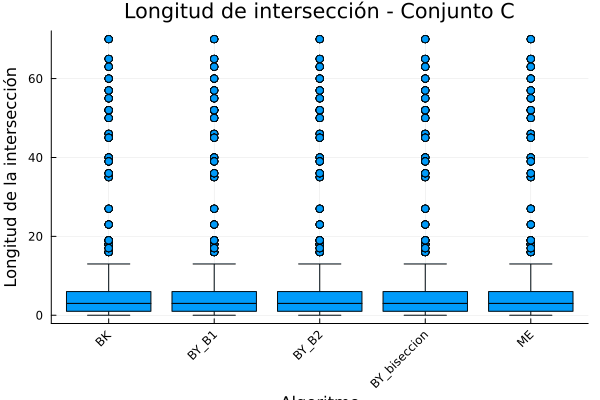

In [97]:
for c in ["A", "B", "C"]
#Filtramos los resultados del conjunto
    df_c = filter(row -> row.conjunto == c, resultados)
#Generamos el boxplot
    p = @df df_c boxplot(
        :algoritmo,
        :longitud_interseccion,
        xlabel = "Algoritmo",
        ylabel = "Longitud de la intersección",
        title = "Longitud de intersección - Conjunto $c",
        xrotation = 45,
        legend = false
    )

    display(p)
end

En el conjunto A, todos los algoritmos muestran la misma distribución en la longitud de la intersección. Esto indica que ME, BK y las versiones de BY están llegando al mismo resultado. También se observan algunos valores atípicos con longitudes más altas, pero aparecen en todos los algoritmos, por lo que no parecen ser errores, sino casos donde las dos listas tenían más elementos en común.

En el conjunto B también se observa que las longitudes son iguales entre algoritmos. La mayoría de las intersecciones se concentra en valores bajos, aunque hay algunos casos con longitudes mucho más altas. Como estos valores se repiten en todos los métodos, se puede interpretar que corresponden a características de los datos.

En el conjunto C las longitudes de intersección son menores en comparación con A y B. Esto es esperado porque aquí se intersectan cuatro listas, por lo que es menos probable que un mismo elemento aparezca en todas. Aun así, las distribuciones son iguales entre algoritmos.

## Discusión
Los gráficos muestran los resultados de los algoritmos ME, BY con bisección, BY con B1, BY con B2 y BK para los conjuntos A, B y C. Se comparan tres aspectos: el tiempo de ejecución, el número de comparaciones y la longitud de la intersección.

En los gráficos de tiempo, se observa que la mayoría de los algoritmos tienen tiempos parecidos. También aparecen algunos valores más altos, principalmente en casos aislados. Esto puede pasar porque algunas ejecuciones tardan más que otras, especialmente al inicio. En general, las diferencias de tiempo no son tan marcadas entre algoritmos.

En los gráficos de comparaciones, sí se observa una diferencia más clara. El algoritmo ME realiza más comparaciones que los demás, sobre todo en los conjuntos B y C. Esto se relaciona con la forma en que trabaja, ya que compara las listas de manera más directa. En cambio, BY y BK hacen menos comparaciones porque aprovechan el orden de las listas para buscar de manera más eficiente.

En los gráficos de longitud de intersección, todos los algoritmos muestran resultados iguales o muy similares dentro de cada conjunto. Esto es importante, porque si un algoritmo estuviera mal, la longitud de su intersección sería distinta. Como las longitudes coinciden, se puede considerar que los algoritmos están calculando correctamente la intersección.

También se observa que las longitudes cambian entre A, B y C. Esto es esperado, porque en A se intersectan dos listas, en B tres listas y en C cuatro listas. Mientras más listas se cruzan, es menos probable que muchos elementos aparezcan en todas. Por eso, las intersecciones tienden a ser más pequeñas cuando aumenta el número de listas.

En general, todos los algoritmos obtienen la misma intersección, pero no con el mismo costo. ME realiza más comparaciones, especialmente cuando aumenta el número de listas. BY y BK resultan más eficientes porque aprovechan el orden de las listas para reducir trabajo. En tiempo, las diferencias son menos evidentes, por lo que el número de comparaciones permite comparar mejor la eficiencia.

## Conclusión
En esta práctica se implementaron tres algoritmos para calcular la intersección de listas ordenadas: ME, BY y BK. El ejercicio permitió ver que un mismo problema puede resolverse de distintas formas, dependiendo de cómo se recorran las listas y de cómo se aproveche que los datos ya están ordenados.

También fue útil trabajar con los conjuntos A, B y C, porque permitió probar los algoritmos con pares, tripletas y tuplas de cuatro listas. La longitud de la intersección ayudó a revisar que los resultados fueran consistentes, ya que todos los algoritmos debían llegar a la misma respuesta para cada caso. 

A partir de los gráficos, se pudo comparar el comportamiento de los algoritmos en tiempo, comparaciones y longitud de la intersección. El resultado general indica que ME realizó más comparaciones, especialmente cuando aumentó el número de listas, mientras que BY y BK mostraron un mejor comportamiento en ese aspecto. En cambio, en el tiempo de ejecución las diferencias fueron pequeñas.

En conclusión, la práctica permitió observar que no basta con obtener el resultado correcto, sino que también es importante revisar cómo llega cada algoritmo a ese resultado y cuánto trabajo requiere. Esto ayuda a entender mejor la relación entre la implementación, los datos utilizados y el desempeño de cada método.

## Referencias 
- Baeza-Yates, R. (2004). A fast set intersection algorithm for sorted sequences. En S. C. Sahinalp, S. Muthukrishnan, U. Dogrusöz, & F. C. Sahinalp (Eds.), Combinatorial Pattern Matching: CPM 2004. Springer.

- Barbay, J., & Kenyon, C. (2002). Adaptive intersection and t-threshold problems. En Proceedings of the 13th Annual ACM-SIAM Symposium on Discrete Algorithms. Society for Industrial and Applied Mathematics.

- Hwang, F. K., & Lin, S. (1971). Optimal merging of 2 elements with n elements. Acta Informatica, 1.